In [6]:
import pandas as pd
import numpy as np

In [7]:
data=pd.read_csv("/content/twitter_training.csv")

In [8]:
data.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [9]:
data.isna().sum()

,0
2401,0
Borderlands,0
Positive,0
"im getting on borderlands and i will murder you all ,",686


In [10]:
data.dropna(inplace=True)

In [11]:
data.drop(["2401","Borderlands"],axis=1,inplace=True)

In [12]:
data.duplicated().sum()

np.int64(4227)

In [13]:
data.drop_duplicates(inplace=True)

In [14]:
data.head()

,Positive,"im getting on borderlands and i will murder you all ,"
0,Positive,I am coming to the borders and I will kill you...
1,Positive,im getting on borderlands and i will kill you ...
2,Positive,im coming on borderlands and i will murder you...
3,Positive,im getting on borderlands 2 and i will murder ...
4,Positive,im getting into borderlands and i can murder y...


In [15]:
data.rename({"Positive":"output","im getting on borderlands and i will murder you all ,":"reviews"},axis=1,inplace=True)

In [16]:
data.output.value_counts()

,count
output,
Negative,21237
Positive,19137
Neutral,17110
Irrelevant,12284


<Axes: xlabel='output'>

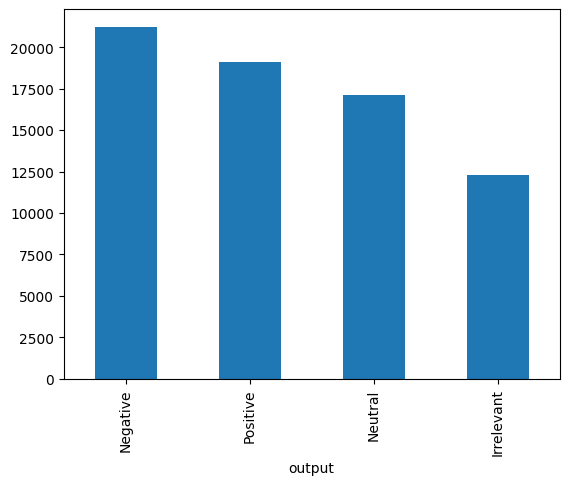

In [17]:
data.output.value_counts().plot(kind='bar')

In [18]:
man={
    "Negative":0,
    "Positive":1,
    "Neutral":2,
    "Irrelevant":3

}

In [19]:
data['output']=data.output.map(man)

In [20]:
data['output'].value_counts()

,count
output,
0,21237
1,19137
2,17110
3,12284


# preprocessing:

In [21]:
# data['reviews'].str.lower()

In [22]:
# def preprocessing():
#     text=data.reviews.str.lower()
#     return text

In [23]:
# preprocessing()

In [24]:
# data['reviews']=text=data.reviews.str.lower()

In [25]:
# data['reviews']

In [26]:
#remove punctuation:

In [27]:
# import string
# string.punctuation

In [28]:
# import string

# translator = str.maketrans('', '', string.punctuation)

# clean_reviews = [review.translate(translator) for review in data['reviews']]

In [29]:
import string
import re
from nltk.corpus import stopwords
def preposs(text):
    text=text.lower()
    text="".join([i for i in text if i not in string.punctuation])
    text=re.sub("\d+","",text)
    text=" ".join([i for i in text.split() if i not in stopwords.words("english")])
    return text


<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-1642938077.py:7: SyntaxWarning: invalid escape sequence '\d'
  text=re.sub("\d+","",text)


In [32]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [33]:
clean_reviews=data.reviews.apply(preposs)

# tokenzation:

In [35]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [38]:
toke=Tokenizer()
toke.fit_on_texts(clean_reviews)
clean_data=toke.texts_to_sequences(clean_reviews)

In [39]:
toke.word_index

{'game': 1,
 'like': 2,
 'get': 3,
 'im': 4,
 'one': 5,
 'good': 6,
 'play': 7,
 'really': 8,
 'new': 9,
 'love': 10,
 'johnson': 11,
 'see': 12,
 'people': 13,
 'shit': 14,
 'time': 15,
 'best': 16,
 '’': 17,
 'still': 18,
 'got': 19,
 'games': 20,
 'even': 21,
 'great': 22,
 'playing': 23,
 'dont': 24,
 'cant': 25,
 'xbox': 26,
 'fucking': 27,
 'go': 28,
 'rhandlerr': 29,
 'facebook': 30,
 'google': 31,
 'please': 32,
 'amazon': 33,
 'dead': 34,
 'fuck': 35,
 'back': 36,
 'verizon': 37,
 'us': 38,
 'microsoft': 39,
 'much': 40,
 'ps': 41,
 'going': 42,
 'fifa': 43,
 'would': 44,
 'red': 45,
 'know': 46,
 'make': 47,
 'home': 48,
 'day': 49,
 'first': 50,
 'fun': 51,
 'today': 52,
 'also': 53,
 'pubg': 54,
 'borderlands': 55,
 'gta': 56,
 'want': 57,
 'fix': 58,
 'ever': 59,
 'bad': 60,
 'nvidia': 61,
 'never': 62,
 'thank': 63,
 'battlefield': 64,
 'unk': 65,
 'x': 66,
 'call': 67,
 'player': 68,
 'thanks': 69,
 'world': 70,
 'video': 71,
 'every': 72,
 'ive': 73,
 'overwatch': 74,
 

# **check the length **

In [40]:
max(len(x) for x in clean_data)

163

# pad_sequence

In [41]:
X=pad_sequences(clean_data,maxlen=163,padding="post")

In [42]:
X

array([[  272,  6193,   298, ...,     0,     0,     0],
       [    4,    80,    55, ...,     0,     0,     0],
       [    4,   272,    55, ...,     0,     0,     0],
       ...,
       [ 1730,   459, 11802, ...,     0,     0,     0],
       [ 1730,   459, 11802, ...,     0,     0,     0],
       [    2,   459, 11802, ...,     0,     0,     0]], dtype=int32)

In [43]:
y=data.output

# split X and y:

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)


In [45]:
X_test

array([[  426,   258,   563, ...,     0,     0,     0],
       [   93,   468,  8371, ...,     0,     0,     0],
       [  949,  5962,  9549, ...,     0,     0,     0],
       ...,
       [  582,  1422, 13609, ...,     0,     0,     0],
       [    2,   238,   544, ...,     0,     0,     0],
       [ 1478,    18,  2676, ...,     0,     0,     0]], dtype=int32)

# RNN:

In [46]:
from tensorflow import keras
from tensorflow.keras import layers

In [52]:
model=keras.Sequential(
    [
        layers.SimpleRNN(128,activation="relu",input_shape=(163,1)),
        layers.Dense(64,activation="relu"),
        layers.Dense(32,activation="relu"),
        layers.Dense(4,activation="softmax")
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [53]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [56]:
model.fit(X_train,y_train ,epochs=15,validation_split=0.2)

Epoch 1/15
1396/1396 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.3023 - loss: 1.3683 - val_accuracy: 0.3006 - val_loss: 1.3698
Epoch 2/15
1396/1396 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.3001 - loss: 1.3673 - val_accuracy: 0.3006 - val_loss: 1.3700
Epoch 3/15
1396/1396 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.3051 - loss: 1.3660 - val_accuracy: 0.3006 - val_loss: 1.3702
Epoch 4/15
1396/1396 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.3070 - loss: 1.3662 - val_accuracy: 0.3006 - val_loss: 1.3706
Epoch 5/15
1396/1396 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.3062 - loss: 1.3663 - val_accuracy: 0.3006 - val_loss: 1.3705
Epoch 6/15
1396/1396 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.3054 - loss: 1.3667 - val_accuracy: 0.3006 - val_loss: 1.3704
Epoch 7/15
1396/1396 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.3017 - loss: 1.3678 - val_accuracy: 0.3006 - val_loss: 1.3704
Epoch 8/15
1396/1396 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.3023 -

In [58]:
pred=model.predict(X_test)

437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [64]:
pred[:5]

array([[0.30457333, 0.2741287 , 0.24893339, 0.1723646 ],
       [0.30457333, 0.2741287 , 0.24893339, 0.1723646 ],
       [0.30457333, 0.2741287 , 0.24893339, 0.1723646 ],
       [0.30457333, 0.2741287 , 0.24893339, 0.1723646 ],
       [0.30457333, 0.2741287 , 0.24893339, 0.1723646 ]], dtype=float32)

In [63]:
y_test[:5]

,output
39301,0
19663,3
5161,0
38735,3
20387,1


In [59]:
import numpy as np
np.argmax(pred, axis=1)

array([0, 0, 0, ..., 0, 0, 0])